In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

#model
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)
import joblib

In [5]:
df = pd.read_csv("diabetesBRFSS.csv")
FEATURES = [
    'HighBP','HighChol','CholCheck','BMI','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity',
    'Fruits','Veggies','GenHlth','Age'
]
TARGET = 'Diabetes_binary'

print("Kolom yang dipakai:\n", FEATURES + [TARGET])

Kolom yang dipakai:
 ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'Age', 'Diabetes_binary']


In [6]:
display(df[FEATURES + [TARGET]].head())
display(df[FEATURES + [TARGET]].tail())

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,9.0,0.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,7.0,0.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,9.0,0.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,11.0,0.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,11.0,0.0


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
253675,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,5.0,0.0
253676,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,11.0,1.0
253677,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0
253678,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,7.0,0.0
253679,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,9.0,1.0


In [7]:
df_sub = df[FEATURES + [TARGET]]
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                253680 non-null  float64
 1   HighChol              253680 non-null  float64
 2   CholCheck             253680 non-null  float64
 3   BMI                   253680 non-null  float64
 4   Smoker                253680 non-null  float64
 5   Stroke                253680 non-null  float64
 6   HeartDiseaseorAttack  253680 non-null  float64
 7   PhysActivity          253680 non-null  float64
 8   Fruits                253680 non-null  float64
 9   Veggies               253680 non-null  float64
 10  GenHlth               253680 non-null  float64
 11  Age                   253680 non-null  float64
 12  Diabetes_binary       253680 non-null  float64
dtypes: float64(13)
memory usage: 25.2 MB


In [8]:
df_sub.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,Age,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,2.511392,8.032119,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,1.068477,3.054220,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,6.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,8.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000,10.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,13.000000,1.000000


In [9]:
df_sub.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
GenHlth                 0
Age                     0
Diabetes_binary         0
dtype: int64

In [10]:
binary_features = [
    'HighBP','HighChol','CholCheck','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity',
    'Fruits','Veggies'
]
for col in binary_features:
    print(f"\n{col}")
    print("Count:")
    print(df[col].value_counts())
    print("\nProportion:")
    print(df[col].value_counts(normalize=True))


HighBP
Count:
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

Proportion:
HighBP
0.0    0.570999
1.0    0.429001
Name: proportion, dtype: float64

HighChol
Count:
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

Proportion:
HighChol
0.0    0.575879
1.0    0.424121
Name: proportion, dtype: float64

CholCheck
Count:
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64

Proportion:
CholCheck
1.0    0.96267
0.0    0.03733
Name: proportion, dtype: float64

Smoker
Count:
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

Proportion:
Smoker
0.0    0.556831
1.0    0.443169
Name: proportion, dtype: float64

Stroke
Count:
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64

Proportion:
Stroke
0.0    0.959429
1.0    0.040571
Name: proportion, dtype: float64

HeartDiseaseorAttack
Count:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

Proportion:
HeartDiseaseorAttack
0.0    0.905814
1.0    0.094186
Name: propor

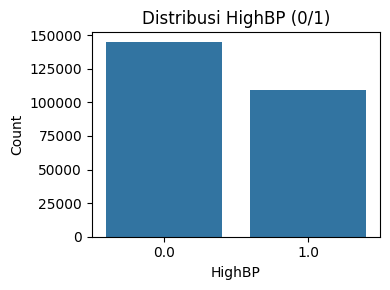

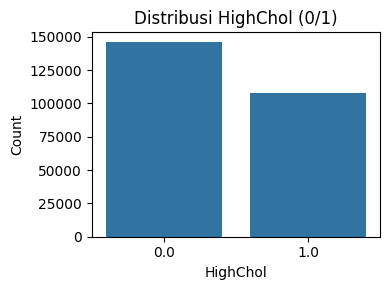

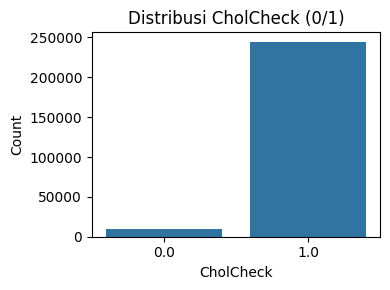

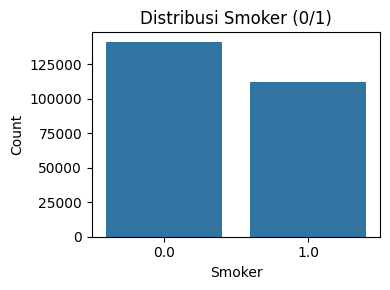

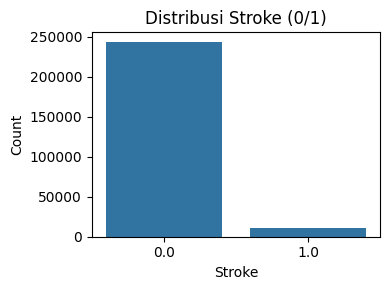

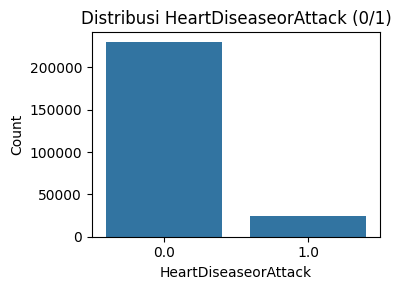

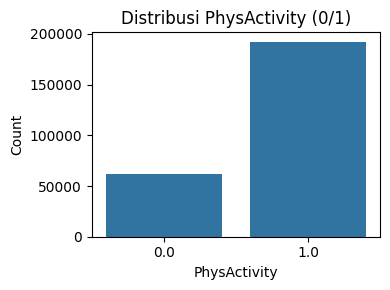

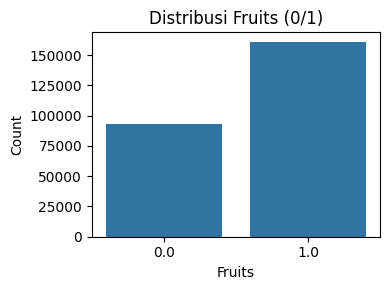

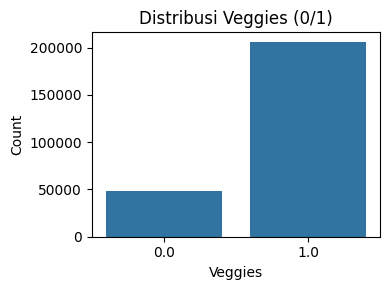

In [11]:
for col in binary_features:
    plt.figure(figsize=(4,3))
    sns.countplot(x=df[col])
    plt.title(f"Distribusi {col} (0/1)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [12]:
print("\nKORELASI FITUR TERHADAP TARGET (Diabetes_binary)")
corr_target = df_sub.corr()[TARGET].sort_values(ascending=False)
print(corr_target)


KORELASI FITUR TERHADAP TARGET (Diabetes_binary)
Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
Stroke                  0.105816
CholCheck               0.064761
Smoker                  0.060789
Fruits                 -0.040779
Veggies                -0.056584
PhysActivity           -0.118133
Name: Diabetes_binary, dtype: float64


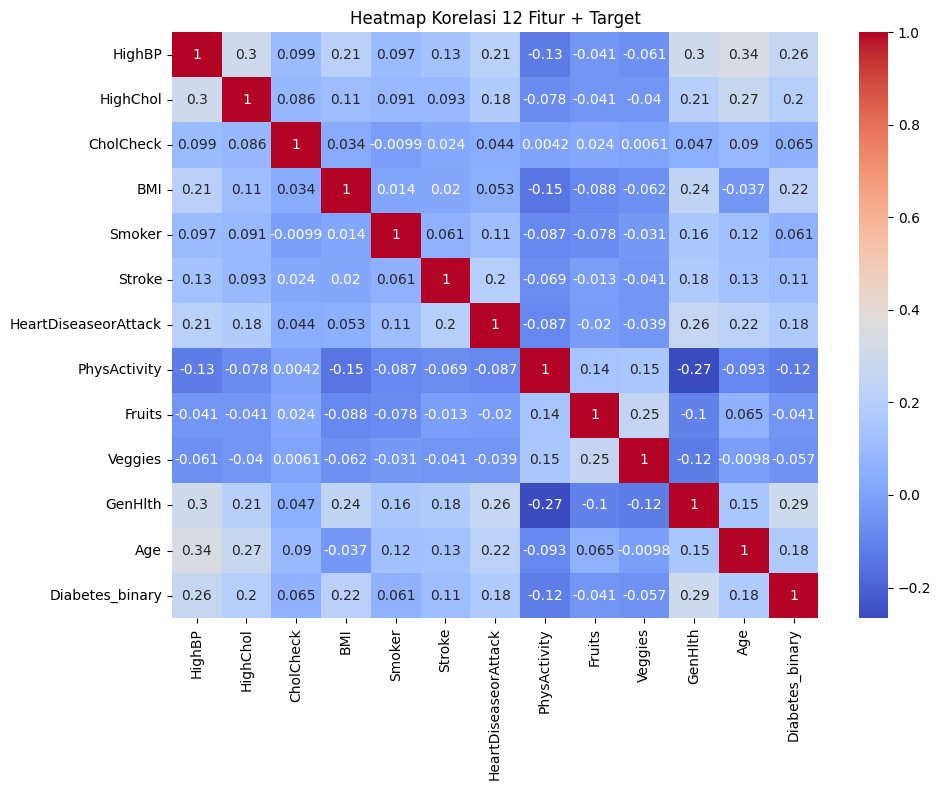

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df_sub.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi 12 Fitur + Target")
plt.tight_layout()
plt.show()

In [14]:
print("\nCROSSTAB FITUR BINARY vs TARGET")
for col in binary_features:
    print(f"\n--- {col} vs {TARGET} (proporsi per nilai {col}) ---")
    ct = pd.crosstab(df[col], df[TARGET], normalize='index')
    print(ct)


CROSSTAB FITUR BINARY vs TARGET

--- HighBP vs Diabetes_binary (proporsi per nilai HighBP) ---
Diabetes_binary       0.0       1.0
HighBP                             
0.0              0.939648  0.060352
1.0              0.755543  0.244457

--- HighChol vs Diabetes_binary (proporsi per nilai HighChol) ---
Diabetes_binary       0.0       1.0
HighChol                           
0.0              0.920186  0.079814
1.0              0.779851  0.220149

--- CholCheck vs Diabetes_binary (proporsi per nilai CholCheck) ---
Diabetes_binary       0.0       1.0
CholCheck                          
0.0              0.974551  0.025449
1.0              0.856251  0.143749

--- Smoker vs Diabetes_binary (proporsi per nilai Smoker) ---
Diabetes_binary       0.0       1.0
Smoker                             
0.0              0.879447  0.120553
1.0              0.837071  0.162929

--- Stroke vs Diabetes_binary (proporsi per nilai Stroke) ---
Diabetes_binary       0.0       1.0
Stroke                        

In [15]:
df['BMI_bin'] = pd.cut(
    df['BMI'],
    bins=[0,18.5,25,30,35,100],
    labels=['underweight','normal','overweight','obese','very_obese']
)

print("\nBMI_bin vs Diabetes_binary (proporsi)")
ct_bmi = pd.crosstab(df['BMI_bin'], df[TARGET], normalize='index')
print(ct_bmi)



BMI_bin vs Diabetes_binary (proporsi)
Diabetes_binary       0.0       1.0
BMI_bin                            
underweight      0.945955  0.054045
normal           0.937525  0.062475
overweight       0.873179  0.126821
obese            0.788473  0.211527
very_obese       0.693599  0.306401


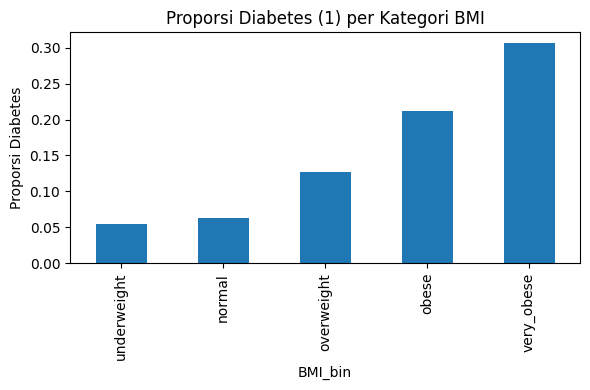

In [16]:
plt.figure(figsize=(6,4))
ct_bmi[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per Kategori BMI")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("BMI_bin")
plt.tight_layout()
plt.show()


GenHlth vs Diabetes_binary (proporsi)
Diabetes_binary       0.0       1.0
GenHlth                            
1.0              0.974834  0.025166
2.0              0.928371  0.071629
3.0              0.822106  0.177894
4.0              0.689895  0.310105
5.0              0.621058  0.378942


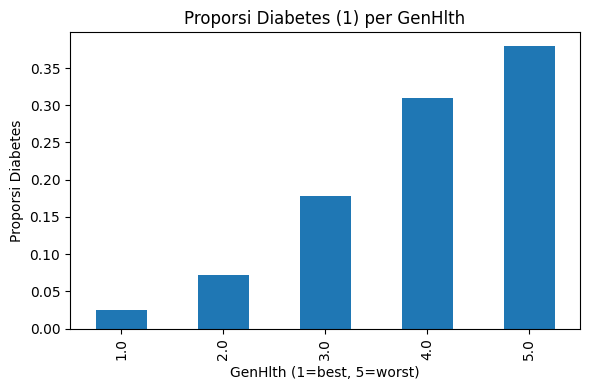

In [17]:
print("\nGenHlth vs Diabetes_binary (proporsi)")
ct_gen = pd.crosstab(df['GenHlth'], df[TARGET], normalize='index')
print(ct_gen)

plt.figure(figsize=(6,4))
ct_gen[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per GenHlth")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("GenHlth (1=best, 5=worst)")
plt.tight_layout()
plt.show()


Age vs Diabetes_binary (proporsi)
Diabetes_binary       0.0       1.0
Age                                
1.0              0.986316  0.013684
2.0              0.981574  0.018426
3.0              0.971770  0.028230
4.0              0.954713  0.045287
5.0              0.934951  0.065049
6.0              0.912105  0.087895
7.0              0.882648  0.117352
8.0              0.861735  0.138265
9.0              0.827548  0.172452
10.0             0.796297  0.203703
11.0             0.781541  0.218459
12.0             0.787046  0.212954
13.0             0.815182  0.184818


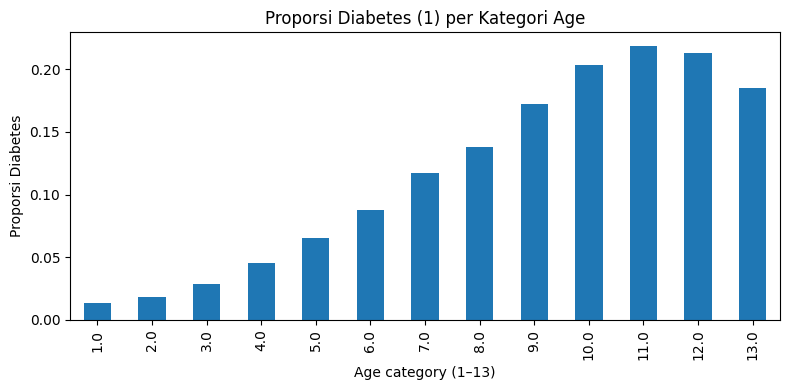

In [18]:
print("\nAge vs Diabetes_binary (proporsi)")
ct_age = pd.crosstab(df['Age'], df[TARGET], normalize='index')
print(ct_age)

plt.figure(figsize=(8,4))
ct_age[1].plot(kind='bar')
plt.title("Proporsi Diabetes (1) per Kategori Age")
plt.ylabel("Proporsi Diabetes")
plt.xlabel("Age category (1–13)")
plt.tight_layout()
plt.show()

# PREPROCESSING

In [19]:
# Buat dataframe kerja hanya dengan 12 fitur + target
df_model = df[FEATURES + [TARGET]].copy()

print("Shape df_model:", df_model.shape)
print("Kolom df_model:", df_model.columns.tolist())

Shape df_model: (253680, 13)
Kolom df_model: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'Age', 'Diabetes_binary']


In [20]:
#CEK CLASS IMBALANCE + HITUNG CLASS WEIGHTS
print("\nDISTRIBUSI KELAS TARGET")
print(df_model[TARGET].value_counts())
print("\nProporsi kelas:")
print(df_model[TARGET].value_counts(normalize=True))


DISTRIBUSI KELAS TARGET
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Proporsi kelas:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


In [21]:
# Hitung class weight untuk dipakai nanti di model.fit()
classes = np.unique(df_model[TARGET])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df_model[TARGET].values
)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

print("CLASS WEIGHTS")
print(class_weight_dict)

CLASS WEIGHTS
{np.float64(0.0): np.float64(0.5809447910082717), np.float64(1.0): np.float64(3.5885248684433884)}


In [22]:
# Pisahkan x dan y
X = df_model[FEATURES].values
y = df_model[TARGET].values

print("\nShape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (253680, 12)
Shape y: (253680,)


In [23]:
# Training + Validation + Test
# Pertama: pisah train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,          # 80% train, 20% sisanya
    random_state=42,
    stratify=y
)

# Kedua: pisah val + test dari temp (masing-masing 10% total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # 10% val, 10% test dari total
    random_state=42,
    stratify=y_temp
)

print("\nSHAPE SPLIT DATA")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

print("\nDistribusi kelas di TRAIN:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nDistribusi kelas di VAL:")
print(pd.Series(y_val).value_counts(normalize=True))
print("\nDistribusi kelas di TEST:")
print(pd.Series(y_test).value_counts(normalize=True))


SHAPE SPLIT DATA
X_train: (202944, 12)  y_train: (202944,)
X_val  : (25368, 12)  y_val  : (25368,)
X_test : (25368, 12)  y_test : (25368,)

Distribusi kelas di TRAIN:
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Distribusi kelas di VAL:
0.0    0.860651
1.0    0.139349
Name: proportion, dtype: float64

Distribusi kelas di TEST:
0.0    0.860691
1.0    0.139309
Name: proportion, dtype: float64


In [24]:
#SCALING / NORMALISASI FITUR NUMERIK
scaler = StandardScaler()

# Fit hanya di TRAIN, lalu transform train/val/test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape  :", X_val_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (202944, 12)
X_val_scaled shape  : (25368, 12)
X_test_scaled shape : (25368, 12)


In [25]:
sns.set(style="whitegrid")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# modelling

In [26]:
# Membangun arsitektur DNN + compile

input_dim = X_train_scaled.shape[1]
print("Input dimension:", input_dim)

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # output binary
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Input dimension: 12


c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,681 (14.38 KB)

 Non-trainable params: 224 (896.00 B)

In [27]:
# EarlyStopping + Training model (model.fit)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/100


c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept 

784/793 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6319 - loss: 0.6107

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


793/793 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6713 - loss: 0.5633 - val_accuracy: 0.7004 - val_loss: 0.5348
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7020 - loss: 0.5253 - val_accuracy: 0.7017 - val_loss: 0.5237
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7041 - loss: 0.5212 - val_accuracy: 0.7062 - val_loss: 0.5210
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7038 - loss: 0.5199 - val_accuracy: 0.7162 - val_loss: 0.5171
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7070 - loss: 0.5181 - val_accuracy: 0.7086 - val_loss: 0.5253
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7078 - loss: 0.5176 - val_accuracy: 0.7075 - val_loss: 0.5174
Epoch 7/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7057 - loss: 0.5181 - val_accuracy: 0.7165 - val_loss: 0.5142
Epoch 8/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7079 - loss: 0.5162 - val_accuracy: 0.7113

,accuracy,loss,val_accuracy,val_loss
23,0.710689,0.513413,0.719686,0.515559
24,0.710452,0.513085,0.702144,0.529517
25,0.710861,0.513333,0.712906,0.517440
26,0.714350,0.512820,0.709752,0.522602
27,0.710137,0.513103,0.724101,0.512794


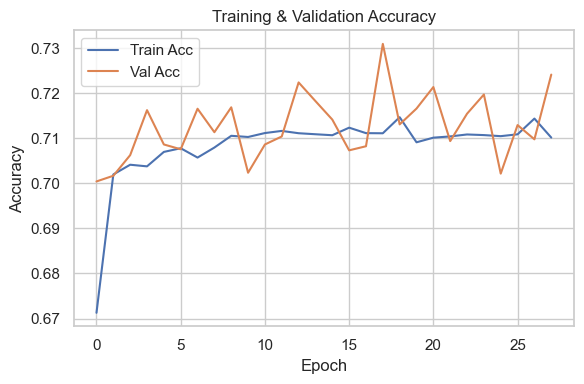

In [28]:
#Plot history training (accuracy & loss)
import pandas as pd
history_df = pd.DataFrame(history.history)
display(history_df.tail())

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


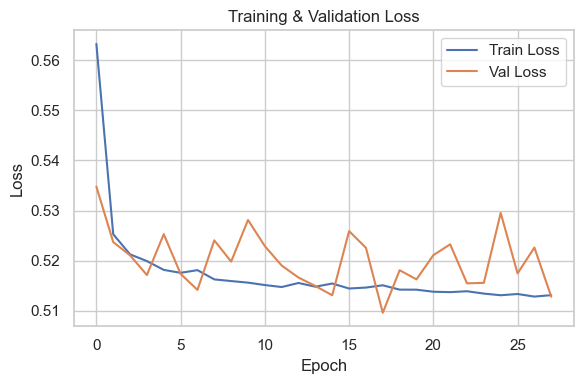

In [29]:
# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Evaluasi: loss, accuracy, precision, recall, F1, ROC-AUC
# Prediksi probabilitas
y_test_prob = model.predict(X_test_scaled).ravel()

793/793 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step


In [31]:
# Threshold default 0.5
y_test_pred = (y_test_prob >= 0.5).astype(int)

In [32]:
# Metrik
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_prob)

print(" METRIK TEST SET ")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred))

 METRIK TEST SET 
Accuracy : 0.7236
Precision: 0.3036
Recall   : 0.7603
F1-score : 0.4339
ROC-AUC  : 0.8160

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     21834
         1.0       0.30      0.76      0.43      3534

    accuracy                           0.72     25368
   macro avg       0.63      0.74      0.63     25368
weighted avg       0.86      0.72      0.76     25368



Confusion Matrix:
 [[15670  6164]
 [  847  2687]]


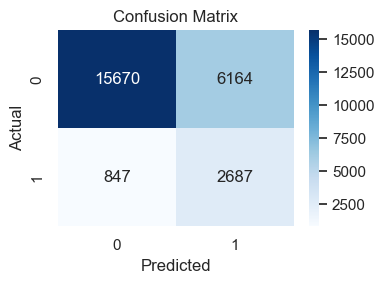

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

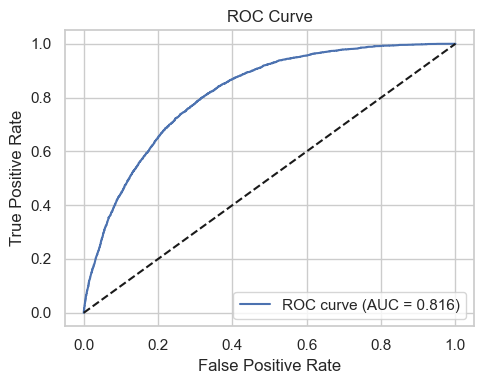

In [34]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
#Simpan model & scaler
# Simpan scaler
joblib.dump(scaler, "scaler_diabetes.pkl")
print("Scaler disimpan sebagai scaler_diabetes.pkl")

# Simpan model Keras
model.save("diabetes_dnn_binary.h5")
print("Model disimpan sebagai diabetes_dnn_binary.h5")

Scaler disimpan sebagai scaler_diabetes.pkl
Model disimpan sebagai diabetes_dnn_binary.h5


c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept 

In [36]:
# INSTALL & IMPORT SHAP

import shap
import numpy as np

shap.initjs()

c:\python\data-mining-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
# Ambil 100 sampel dari train sebagai background
np.random.seed(42)
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

f = lambda x: model.predict(x).ravel()

explainer = shap.KernelExplainer(f, background)

# Ambil hanya 50 sampel test buat interpretasi
X_test_sample = X_test_scaled[:50]

# Batasi nsamples biar gak terlalu berat
shap_values = explainer.shap_values(X_test_sample, nsamples=100)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 59/313 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step


  2%|▏         | 1/50 [00:00<00:22,  2.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 67/313 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


  4%|▍         | 2/50 [00:00<00:21,  2.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 62/313 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step


  6%|▌         | 3/50 [00:01<00:21,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step


  8%|▊         | 4/50 [00:01<00:21,  2.13it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 57/313 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step


 10%|█         | 5/50 [00:02<00:21,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


 12%|█▏        | 6/50 [00:02<00:20,  2.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 68/313 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step


 14%|█▍        | 7/50 [00:03<00:19,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 64/313 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step


 16%|█▌        | 8/50 [00:03<00:18,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 69/313 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step


 18%|█▊        | 9/50 [00:04<00:18,  2.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 35/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


 20%|██        | 10/50 [00:04<00:19,  2.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 61/313 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step


 22%|██▏       | 11/50 [00:05<00:18,  2.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 62/313 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step


 24%|██▍       | 12/50 [00:05<00:17,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 70/313 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step


 26%|██▌       | 13/50 [00:05<00:16,  2.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step


 28%|██▊       | 14/50 [00:06<00:16,  2.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
  1/313 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step


 30%|███       | 15/50 [00:06<00:16,  2.13it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step


 32%|███▏      | 16/50 [00:07<00:15,  2.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 70/313 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step


 34%|███▍      | 17/50 [00:07<00:15,  2.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step


 36%|███▌      | 18/50 [00:08<00:14,  2.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 56/313 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step


 38%|███▊      | 19/50 [00:08<00:14,  2.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 67/313 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step


 40%|████      | 20/50 [00:09<00:13,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 69/313 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step


 42%|████▏     | 21/50 [00:09<00:12,  2.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 66/313 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


 44%|████▍     | 22/50 [00:10<00:12,  2.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 69/313 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


 46%|████▌     | 23/50 [00:10<00:11,  2.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 60/313 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step


 48%|████▊     | 24/50 [00:10<00:11,  2.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 64/313 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step


 50%|█████     | 25/50 [00:11<00:11,  2.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 32/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


 52%|█████▏    | 26/50 [00:11<00:11,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 69/313 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step


 54%|█████▍    | 27/50 [00:12<00:10,  2.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step


 56%|█████▌    | 28/50 [00:12<00:10,  2.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 71/313 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step


 58%|█████▊    | 29/50 [00:13<00:09,  2.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 67/313 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step


 60%|██████    | 30/50 [00:13<00:08,  2.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step


 62%|██████▏   | 31/50 [00:14<00:08,  2.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step


 64%|██████▍   | 32/50 [00:14<00:07,  2.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 58/313 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step


 66%|██████▌   | 33/50 [00:14<00:07,  2.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 60/313 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step


 68%|██████▊   | 34/50 [00:15<00:07,  2.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 64/313 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step


 70%|███████   | 35/50 [00:15<00:06,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step


 72%|███████▏  | 36/50 [00:16<00:06,  2.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step


 74%|███████▍  | 37/50 [00:16<00:06,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step


 76%|███████▌  | 38/50 [00:17<00:05,  2.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 70/313 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step


 78%|███████▊  | 39/50 [00:17<00:05,  2.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 57/313 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step


 80%|████████  | 40/50 [00:18<00:04,  2.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 62/313 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step


 82%|████████▏ | 41/50 [00:18<00:04,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 65/313 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


 84%|████████▍ | 42/50 [00:19<00:03,  2.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 73/313 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step


 86%|████████▌ | 43/50 [00:19<00:03,  2.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
 68/313 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step


 88%|████████▊ | 44/50 [00:19<00:02,  2.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 67/313 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


 90%|█████████ | 45/50 [00:20<00:02,  2.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 56/313 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step


 92%|█████████▏| 46/50 [00:20<00:01,  2.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step


 94%|█████████▍| 47/50 [00:21<00:01,  2.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
 64/313 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step


 96%|█████████▌| 48/50 [00:21<00:00,  2.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
  1/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


 98%|█████████▊| 49/50 [00:22<00:00,  2.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 58/313 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step

c:\python\data-mining-project\.venv\Lib\site-packages\keras\src\utils\python_utils.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  value = float(value)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step


100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


C:\Users\Arifi\AppData\Local\Temp\ipykernel_24196\1300718938.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


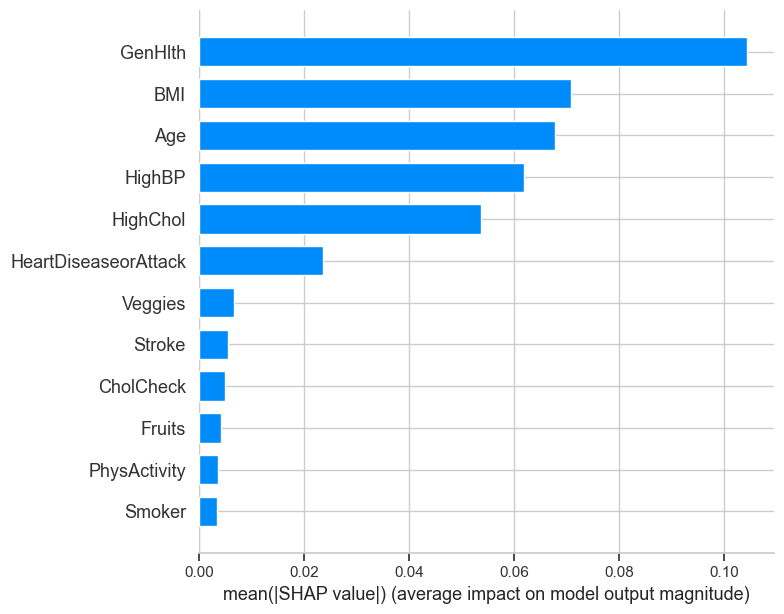

In [38]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ],
    plot_type='bar'
)

C:\Users\Arifi\AppData\Local\Temp\ipykernel_24196\534828583.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


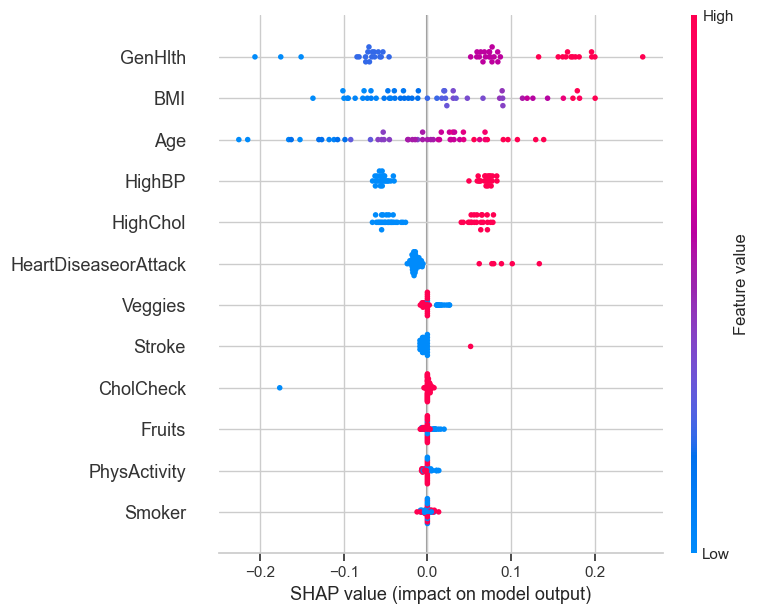

In [39]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ]
)


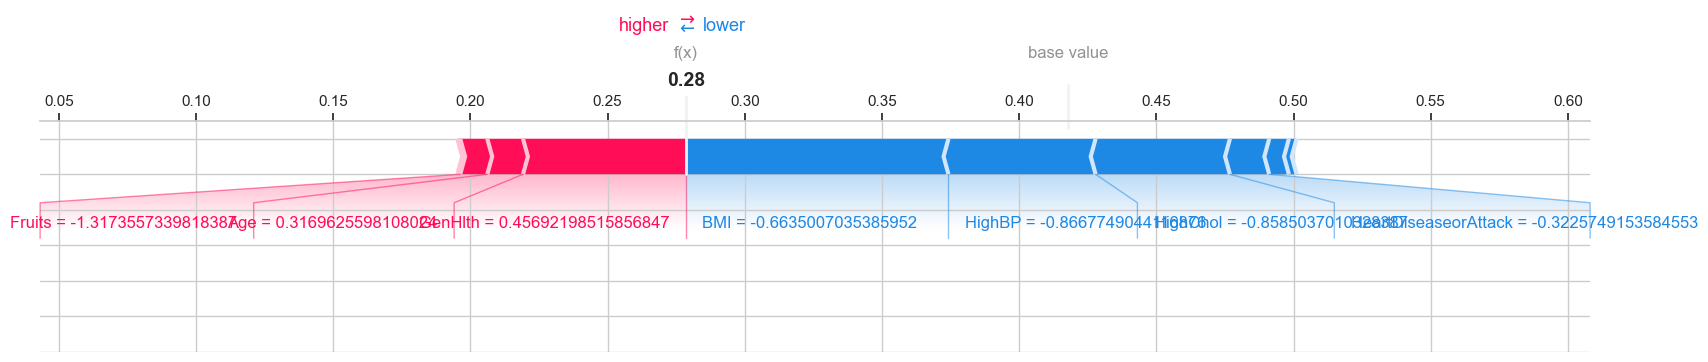

In [40]:
i = 0 
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_sample[i],
    feature_names=[
        'HighBP','HighChol','CholCheck','BMI','Smoker',
        'Stroke','HeartDiseaseorAttack','PhysActivity',
        'Fruits','Veggies','GenHlth','Age'
    ],
    matplotlib=True
)


# ***CLUSTERING***

In [41]:
from sklearn.cluster import KMeans
selected_features = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 
    'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 
    'Fruits', 'Veggies', 'GenHlth', 'Age'
]
df_cluster = df[selected_features].copy()

In [42]:
# Normalisasi untuk clusterisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
print(f"Jumlah Fitur: {X_scaled.shape[1]}")

Jumlah Fitur: 12


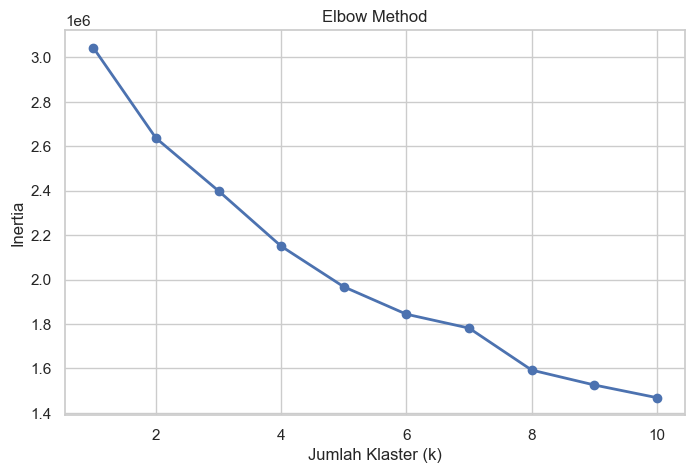

In [43]:
#ELBOW METHOD (Mencari K Optimal)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, max_iter=300, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Plot Grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [44]:
k_pilihan = 3

kmeans_final = KMeans(n_clusters=k_pilihan, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_cluster['Cluster'] = cluster_labels

print(f"\nKlustering selesai dengan {k_pilihan} klaster.")
print(df_cluster['Cluster'].value_counts())


Klustering selesai dengan 3 klaster.
Cluster
0    123617
2    100212
1     29851
Name: count, dtype: int64


In [45]:
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
X_sample, y_sample = resample(X_scaled, cluster_labels, n_samples=10000, random_state=42)
score = silhouette_score(X_sample, y_sample)
print(f"\nSilhouette Score: {score:.4f}")


Silhouette Score: 0.1419


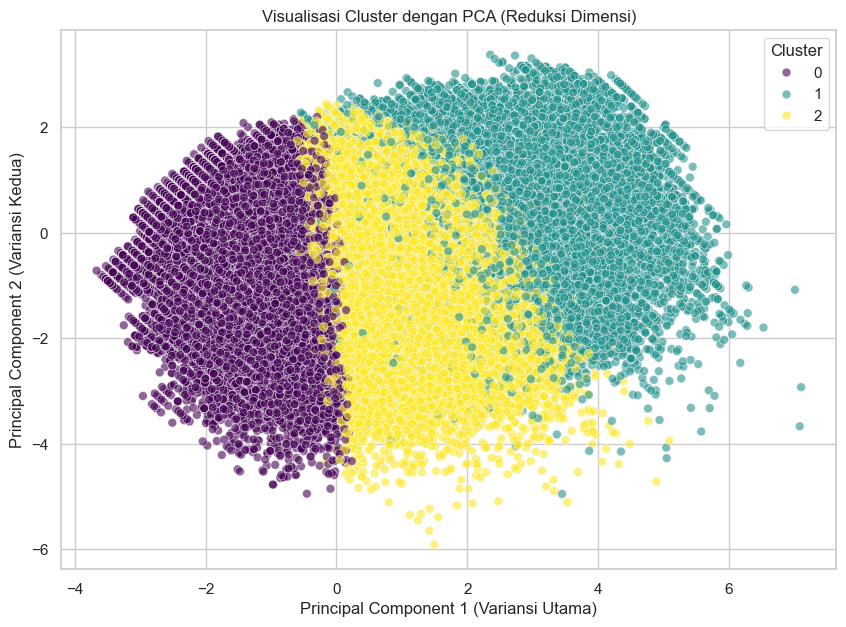

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Buat DataFrame hasil PCA
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

# Plot PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1", y="PC2", hue="Cluster", data=pca_df, 
    palette="viridis", alpha=0.6, s=40
)
plt.title('Visualisasi Cluster dengan PCA (Reduksi Dimensi)')
plt.xlabel('Principal Component 1 (Variansi Utama)')
plt.ylabel('Principal Component 2 (Variansi Kedua)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

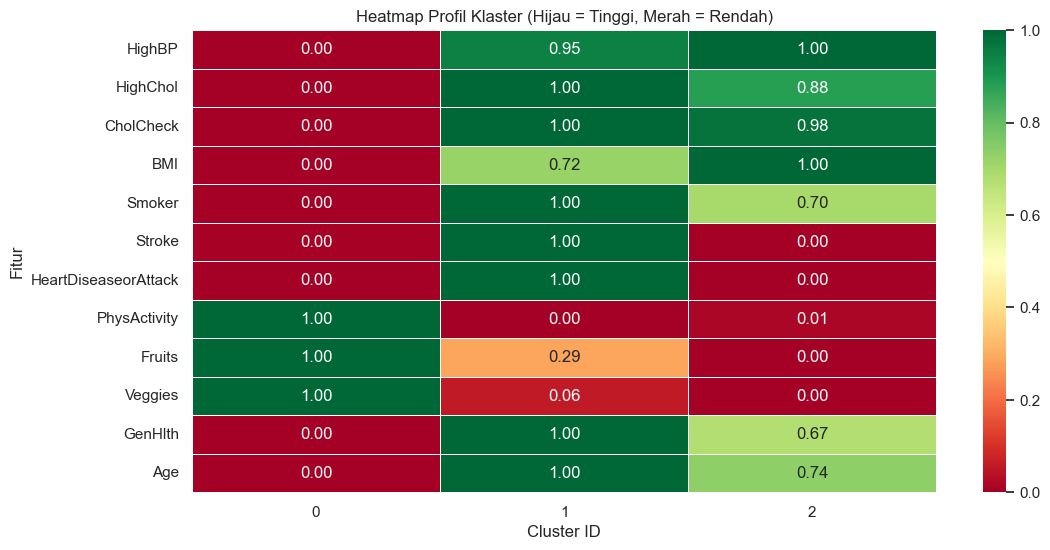

In [47]:
cluster_means = df_cluster.groupby('Cluster').mean()
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_scaled.T, cmap="RdYlGn", annot=True, fmt=".2f", linewidths=.5)
plt.title('Heatmap Profil Klaster (Hijau = Tinggi, Merah = Rendah)')
plt.xlabel('Cluster ID')
plt.ylabel('Fitur')
plt.show()

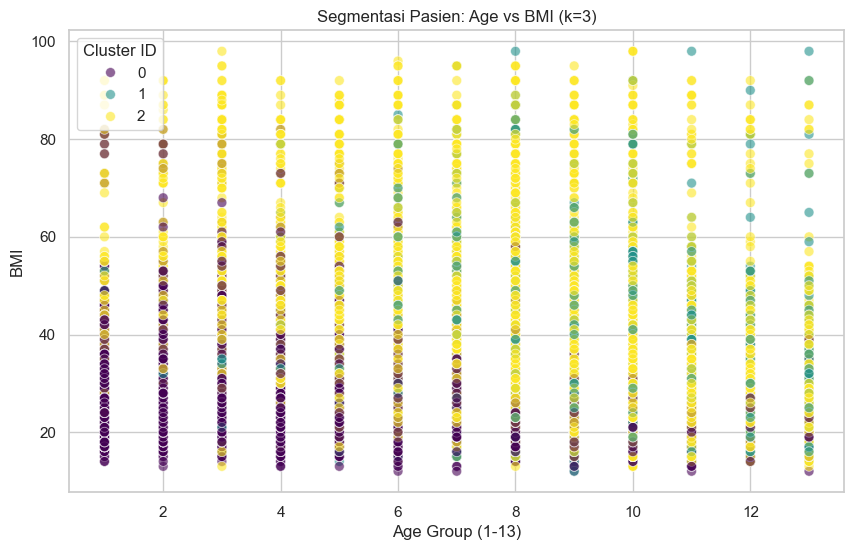

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster, 
    x='Age', 
    y='BMI', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=50
)
plt.title(f'Segmentasi Pasien: Age vs BMI (k={k_pilihan})')
plt.xlabel('Age Group (1-13)')
plt.ylabel('BMI')
plt.legend(title='Cluster ID')
plt.show()

In [49]:
for i in range(k):
    print(f"\nCLUSTER {i}:")
    print("----------------")
    # Cari fitur yang nilainya paling ekstrem (Sangat Tinggi atau Sangat Rendah) di klaster ini
    # Dibandingkan rata-rata global
    global_mean = df_cluster.drop(columns=['Cluster']).mean()
    cluster_mean = df_cluster[df_cluster['Cluster'] == i].mean()
    
    # Hitung selisih relatif
    diff = (cluster_mean - global_mean) / global_mean
    
    # Ambil top 3 fitur yang lebih tinggi dari rata-rata
    top_features = diff.nlargest(3)
    print(f"Fitur Dominan (Lebih tinggi dari rata-rata populasi):")
    for feat, val in top_features.items():
        print(f"  - {feat}: {cluster_mean[feat]:.2f} ({(val*100):.1f}% di atas rata-rata)")


CLUSTER 0:
----------------
Fitur Dominan (Lebih tinggi dari rata-rata populasi):
  - PhysActivity: 0.88 (16.4% di atas rata-rata)
  - Fruits: 0.70 (10.0% di atas rata-rata)
  - Veggies: 0.87 (7.8% di atas rata-rata)

CLUSTER 1:
----------------
Fitur Dominan (Lebih tinggi dari rata-rata populasi):
  - HeartDiseaseorAttack: 0.79 (743.0% di atas rata-rata)
  - Stroke: 0.34 (732.8% di atas rata-rata)
  - HighBP: 0.75 (74.5% di atas rata-rata)

CLUSTER 2:
----------------
Fitur Dominan (Lebih tinggi dari rata-rata populasi):
  - HighBP: 0.79 (83.1% di atas rata-rata)
  - HighChol: 0.63 (48.4% di atas rata-rata)
  - Smoker: 0.53 (19.0% di atas rata-rata)

CLUSTER 3:
----------------
Fitur Dominan (Lebih tinggi dari rata-rata populasi):
  - Age: nan (nan% di atas rata-rata)
  - BMI: nan (nan% di atas rata-rata)
  - CholCheck: nan (nan% di atas rata-rata)

CLUSTER 4:
----------------
Fitur Dominan (Lebih tinggi dari rata-rata populasi):
  - Age: nan (nan% di atas rata-rata)
  - BMI: nan (na

In [67]:
import joblib

# Simpan Model K-Means
joblib.dump(kmeans_final, 'kmeans_model.pkl')
print("Model Clustering berhasil disimpan sebagai 'kmeans_model.pkl'")

joblib.dump(scaler, 'scaler_clustering.pkl') 
print("Scaler Clustering berhasil disimpan sebagai 'scaler_clustering.pkl'")

Model Clustering berhasil disimpan sebagai 'kmeans_model.pkl'
Scaler Clustering berhasil disimpan sebagai 'scaler_clustering.pkl'


# ***ASOSIASI***

In [50]:
df_assoc = df[selected_features].copy()

In [58]:
df_assoc = df[selected_features].sample(n=10500, random_state=42).copy()

In [59]:
# 2. DISCRETIZATION (Syarat Wajib Soal)
# ==========================================
# Mengubah angka menjadi label teks agar Rules-nya bisa dibaca manusia
# Contoh: BMI 35 -> "BMI_Obese", bukan angka 35

# A. Binning BMI (Standard WHO)
df_assoc['BMI_Group'] = pd.cut(df_assoc['BMI'], 
                            bins=[0, 25, 30, 100], 
                            labels=['BMI_Normal', 'BMI_Over', 'BMI_Obese'])

# B. Binning Age (Asumsi pembagian umur BRFSS)
# 1-4: Dewasa Muda, 5-9: Paruh Baya, 10-13: Lansia
df_assoc['Age_Group'] = pd.cut(df_assoc['Age'], 
                            bins=[0, 4, 9, 14], 
                            labels=['Age_Young', 'Age_Mid', 'Age_Senior'])

# C. Binning GenHlth (1=Excellent s/d 5=Poor)
df_assoc['Hlth_Status'] = pd.cut(df_assoc['GenHlth'], 
                            bins=[0, 2, 3, 6], 
                            labels=['Hlth_Good', 'Hlth_Fair', 'Hlth_Poor'])

# Hapus kolom angka asli yang sudah diubah (BMI, Age, GenHlth)
df_assoc.drop(columns=['BMI', 'Age', 'GenHlth'], inplace=True)

In [60]:
#ONE-HOT ENCODING (Format Wajib Apriori)
# Mengubah data jadi True/False.

# Ubah kolom binary (0.0/1.0) menjadi string "Yes"/"No" dulu biar labelnya jelas
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
            'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies']

for col in binary_cols:
    df_assoc[col] = df_assoc[col].map({1.0: f'{col}_Yes', 0.0: f'{col}_No'})

# Lakukan One-Hot Encoding
df_encoded = pd.get_dummies(df_assoc)

# Konversi ke Boolean (True/False)
df_encoded = df_encoded.astype(bool)

print("Data siap untuk Apriori.")
print(f"Jumlah Kolom Transaksi: {df_encoded.shape[1]}")

Data siap untuk Apriori.
Jumlah Kolom Transaksi: 27


In [62]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
import time
#EKSEKUSI APRIORI
# # Min Support = 0.05 (5%)
# frequent_itemsets = fpgrowth(df_encoded, min_support=0.05, use_colnames=True)  
start_time = time.time()

frequent_itemsets = fpgrowth(df_encoded, min_support=0.1, use_colnames=True)

print(f"Selesai dalam {time.time() - start_time:.2f} detik!")

Selesai dalam 109.19 detik!


In [66]:
#GENERATE RULES & FILTER
# Confidence min 0.6 (60%)
# Lift > 1.5 (Korelasi Kuat)

print("Membuat Aturan Asosiasi...")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# Filter Lift > 1.5
strong_rules = rules[rules['lift'] > 1.5].copy()

# Sortir berdasarkan Lift tertinggi (Paling Kuat)
strong_rules = strong_rules.sort_values(by='lift', ascending=False)

# Tampilkan Top 10 Aturan untuk Laporan
print(f"\nDitemukan {len(strong_rules)} aturan kuat (Lift > 1.5).")
print("\nTOP 5 RULES")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Membuat Aturan Asosiasi...

Ditemukan 3377 aturan kuat (Lift > 1.5).

TOP 5 RULES
                                             antecedents  \
53628                              (Age_Group_Age_Young)   
53567                              (Age_Group_Age_Young)   
53623            (Stroke_Stroke_No, Age_Group_Age_Young)   
53563            (Stroke_Stroke_No, Age_Group_Age_Young)   
53582                              (Age_Group_Age_Young)   
53538                              (Age_Group_Age_Young)   
53627     (Age_Group_Age_Young, CholCheck_CholCheck_Yes)   
53626  (HeartDiseaseorAttack_HeartDiseaseorAttack_No,...   
53566  (HeartDiseaseorAttack_HeartDiseaseorAttack_No,...   
53616  (Stroke_Stroke_No, CholCheck_CholCheck_Yes, Ag...   

                                             consequents   support  \
53628  (Stroke_Stroke_No, HighBP_HighBP_No, HighChol_...  0.104286   
53567  (HighBP_HighBP_No, HighChol_HighChol_No, Strok...  0.111905   
53623  (HighBP_HighBP_No, HighChol_HighChol_No,

In [65]:
#PENJELASAN 
if not strong_rules.empty:
    row = strong_rules.iloc[0]
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    lft = row['lift']
    print(f"JIKA Pasien punya kondisi [{ant}],")
    print(f"MAKA Dia berkemungkinan besar punya [{con}].")
    print(f"Kekuatan hubungan (Lift): {lft:.2f} kali lipat lebih berisiko dibanding orang biasa.")
else:
    print("Tidak ditemukan aturan dengan Lift > 1.5. Coba turunkan min_confidence jadi 0.5 atau min_support jadi 0.01.")

JIKA Pasien punya kondisi [Age_Group_Age_Young],
MAKA Dia berkemungkinan besar punya [Stroke_Stroke_No].
Kekuatan hubungan (Lift): 1.91 kali lipat lebih berisiko dibanding orang biasa.
